# RaSA - Modelo Dimensional

## Tarea 2: Modelado de Datos y ETL - MIAD

Objetivo: Proponer un modelo multidimensional para el proceso de negocio OfertaPlanes (de periodicidad anual) que soporte los análisis solicitados por RaSA,y diseñar el proceso ETL para poblar las tablas del modelo a partir de las fuentes transaccionales ya exploradas en el Entendimiento de Datos.

Entregables de esta tarea:
- Entregable 1: Modelo multidimensional (con historia de atributos de dimensiones)
- Entregable 2: Diseño del proceso ETL (plantilla en PDF)

Referencia: los hallazgos de calidad de datos citados en este documento provienen del notebook RaSA-Entendimiento_Datos.ipynb (Entrega 1).

## 1. Análisis de requerimientos: de las preguntas de negocio al modelo

Antes de proponer dimensiones y tabla de hechos, se traduce cada análisis solicitado por RaSA en sus requerimientos de modelado: qué debe medirse, por qué dimensiones debe poder cortarse o filtrarse, y qué nivel de detalle (grano) exige.

| Análisis | Qué debe medirse | Por qué dimensiones se corta | Grano exigido |
|---|---|---|---|
| 1. Comportamiento desleal de proveedores (1.a, 1.b) | Diferencia porcentual (mayor a 20%) en valorCopago/valorCoseguro entre proveedores, para un mismo tipo de beneficio | Proveedor, Tipo de Beneficio, Fecha (rango de fechas) | Debe permitir comparar valores de copago/coseguro por proveedor y tipo de beneficio, no agregado - se necesita el detalle a nivel de plan individual |
| 2. Cobertura de planes (2.a, 2.b, 2.c) | Conteo de áreas de servicio cubiertas; conteo de proveedores por área | Área de Servicio, Proveedor, Fecha (rango de años) | Se necesita saber, para cada área, cuántos proveedores o planes la cubren - grano a nivel de área más proveedor más año como mínimo |
| 3. Concentraciones de planes (3.a, 3.b) | Conteo de planes por área/estado/condado; contraste contra población | Área de Servicio (con jerarquía Condado-Estado), Fecha | Requiere que la dimensión de Área de Servicio tenga jerarquía geográfica explícita (Condado, Estado) y el atributo de población |
| 4. Evolución de planes (4.a, 4.b) | Evolución de valorCopago/valorCoseguro y presencia de tipos de beneficio en el tiempo | Tipo de Beneficio, Proveedor, Fecha (serie temporal) | Requiere granularidad temporal por año como mínimo, con historia de atributos en Tipo de Beneficio (para poder ver si cambian condiciones como TieneLimiteCuantitativo de un año a otro) |

Conclusión preliminar de esta tabla: los 4 análisis convergen en la necesidad de un grano de hechos a nivel de plan de salud (la unidad más fina disponible en las
fuentes), cruzado por proveedor, área de servicio, tipo de beneficio, y condición de pago, con periodicidad anual. Esto es consistente con lo que el enunciado ya
adelantó: el proceso de negocio OfertaPlanes es anual.

## 2. Definición del grano de la tabla de hechos

El proceso de negocio a modelar es OfertaPlanes, de periodicidad anual (dato confirmado en el enunciado). La pregunta de diseño es: qué representa un hecho dentro de este proceso.

### Candidatos de grano evaluados

| Opción de grano | Descripción | Soporta los 4 análisis |
|---|---|---|
| Un registro por proveedor/año | Demasiado agregado, pierde el detalle por tipo de beneficio y área | No permite Análisis 1 (comparar copago por tipo de beneficio) ni 3 (concentración por área) |
| Un registro por plan/año | Agregado a nivel de plan completo, sin desagregar por beneficio | No permite comparar condiciones de pago por tipo de beneficio específico (Análisis 1, 4) |
| Un registro por plan más tipo de beneficio más área de servicio más condición de pago, por año | El nivel más fino disponible en las fuentes, corresponde directamente al grano ya identificado en PlanesBeneficio (Entrega 1, sección 4.2) | Soporta los 4 análisis, ya que permite agregar hacia arriba (por proveedor, por área, por tipo de beneficio) sin perder detalle |

### Grano seleccionado

Un hecho representa la oferta de un tipo de beneficio específico, dentro de un plan de salud, en un área de servicio determinada, con una condición de pago asociada, para un año dado.

Este grano corresponde directamente al nivel de detalle que ya identificamos para PlanesBeneficio en la Entrega 1 (sección 4.2: "cada fila representa la asignación de un tipo de beneficio específico a un plan de salud, en un área de servicio determinada, con sus condiciones de pago"). Esta continuidad es intencional: al mantener el mismo grano que la fuente transaccional más detallada, evitamos pérdida de información y agregaciones prematuras que limitarían análisis futuros no contemplados en la matriz actual, atendiendo la recomendación del enunciado de "hacer un balance entre lo proporcionado por las fuentes y los tipos de análisis que tiene hasta este momento".

### Advertencia de calidad heredada de la fuente

Este grano hereda dos problemas de calidad ya documentados en la Entrega 1 que deben
resolverse en el diseño del ETL (sección de esta tarea), no en el modelo dimensional:

- 46.72% de las filas de PlanesBeneficio están duplicadas a nivel de fila completa (sección 4.4, Entrega 1). El ETL debe deduplicar antes de cargar la tabla de hechos, o la tabla de hechos heredará el mismo problema.
- Integridad referencial rota hacia TiposBeneficio (108 huérfanos) y AreasDeServicio (1,098 huérfanos). El ETL debe decidir explícitamente cómo tratar estas filas (excluir, o cargar con una fila "Desconocido" en la dimensión correspondiente, enfoque estándar de Kimball para manejar huérfanos).

## 3. Identificación de dimensiones

A partir del grano definido, se identifican las siguientes dimensiones candidatas:

### 3.1 Dim_Proveedor

Atributos: IdProveedor_DWH (llave sustituta), IdProveedor_T (llave natural), NombreProveedor (si se logra obtener de una fuente adicional, no está disponible en las fuentes actuales, ver dudas de la Entrega 1).

Requiere historia: No se identificó evidencia en la Entrega 1 de que los atributos de proveedor cambien en el tiempo. Se modela como dimensión estándar (sin SCD Tipo 2), salvo que RaSA confirme lo contrario.

### 3.2 Dim_AreaServicio

Atributos: IdAreaServicio_DWH (llave sustituta), IdAreaDeServicio_T (llave natural), Condado, Estado, PoblacionAct, Area, Densidad, con jerarquía geográfica explícita Condado - Estado, necesaria para el Análisis 3 (concentración por condado/estado).

Requiere historia: Sí. En la Entrega 1 (sección 2.4) se identificó que PoblacionAct y Densidad son atributos que cambian año a año para una misma área, de hecho, esta es la razón por la que la fuente reporta duplicados aparentes en la combinación área más condado (valores distintos de población en distintos registros). Se modela como SCD Tipo 2, preservando el histórico de población/densidad por año, en vez de sobrescribir el valor.

### 3.3 Dim_TipoBeneficio

Atributos: IdTipoBeneficio_DWH (llave sustituta), IdTipoBeneficio_T (llave natural), Nombre, UnidadDelLimite, EsEHB, EstaCubiertaPorSeguro, TieneLimiteCuantitativo, ExcluidoDelDesembolsoMaximoDentroDeLaRed, ExcluidoDelDesembolsoMaximoFueraDeLaRed.

Requiere historia: Sí, de forma crítica. En la Entrega 1 (sección 3.2) se encontró que 161 combinaciones de tipo más año presentan configuraciones distintas de estos atributos (EsEHB, TieneLimiteCuantitativo, etc.), sin que existiera una llave natural completa en la fuente para diferenciarlas. Modelar esta dimensión como SCD Tipo 2 (con fecha de inicio y fin de vigencia por versión de atributos) resuelve formalmente el problema que en la Entrega 1 quedó documentado como duda estructural: cada configuración distinta pasa a ser una versión válida y fechada del tipo de beneficio, en vez de un conflicto de llave sin explicación.

### 3.4 Dim_CondicionPago

Atributos: IdCondicionPago_DWH (llave sustituta), IdCondicionesDePago_T (llave natural), Descripcion, Tipo (Copago/Coseguro).

Requiere historia: No, es un catálogo de referencia estable. El hallazgo de la Entrega 1 (ID 204 con dos descripciones distintas) no es un caso de evolución
temporal, sino un problema de calidad de la fuente que debe resolverse en el ETL (desambiguar antes de cargar), no modelarse como historia.

### 3.5 Dim_Tiempo

Atributos: IdTiempo_DWH (llave sustituta), Anio (dado que el proceso de negocio es anual, esta dimensión puede ser minimalista, no se requiere nivel de día o mes salvo que RaSA solicite análisis de mayor granularidad temporal a futuro).

Requiere historia: No aplica, es la dimensión que registra el tiempo en sí.

### 3.6 Plan: dimensión o atributo degenerado

IdPlan_T no tiene atributos propios más allá de su identificador (no hay nombre de plan, descripción, ni categoría asociada en las fuentes disponibles). Siguiendo el
principio de Kimball de dimensión degenerada, se modela IdPlan_T como un atributo directamente en la tabla de hechos, sin crear una tabla de dimensión separada, esto evita una dimensión vacía que no aportaría atributos para analizar.

### Resumen

| Dimensión | Tipo | Historia (SCD) |
|---|---|---|
| Dim_Proveedor | Dimensión estándar | No (SCD Tipo 1) |
| Dim_AreaServicio | Dimensión con jerarquía | Sí (SCD Tipo 2) |
| Dim_TipoBeneficio | Dimensión con jerarquía de atributos | Sí (SCD Tipo 2) |
| Dim_CondicionPago | Catálogo de referencia | No (SCD Tipo 1) |
| Dim_Tiempo | Dimensión de tiempo | No aplica |
| IdPlan_T | Dimensión degenerada (en la tabla de hechos) | No aplica |

## 4. Tabla de hechos: Hechos_OfertaPlanes

### 4.1 Grano (recordatorio)

Un hecho representa la oferta de un tipo de beneficio específico, dentro de un plan de salud, en un área de servicio determinada, con una condición de pago asociada, para un año dado.

### 4.2 Llaves foráneas

| Columna | Dimensión referenciada |
|---|---|
| IdProveedor_DWH | Dim_Proveedor |
| IdAreaServicio_DWH | Dim_AreaServicio (versión vigente para el año del hecho) |
| IdTipoBeneficio_DWH | Dim_TipoBeneficio (versión vigente para el año del hecho) |
| IdCondicionPagoCopago_DWH | Dim_CondicionPago (rol: Copago) |
| IdCondicionPagoCoseguro_DWH | Dim_CondicionPago (rol: Coseguro) |
| IdTiempo_DWH | Dim_Tiempo |

Las llaves hacia Dim_AreaServicio y Dim_TipoBeneficio deben apuntar a la versión (SCD Tipo 2) vigente en el año del hecho, no a la llave natural directamente. Esto es lo que permite que la historia de atributos tenga efecto real en los análisis (por ejemplo, comparar el copago de un tipo de beneficio bajo la configuración vigente en 2017 contra la configuración vigente en 2018).

### 4.3 Atributo degenerado

| Columna | Descripción |
|---|---|
| IdPlan_T | Identificador del plan de salud, sin tabla de dimensión propia (ver sección 3.6) |

### 4.4 Medidas

| Medida | Tipo | Descripción |
|---|---|---|
| valorCopago | Aditiva | Valor del copago aplicado al beneficio dentro del plan |
| valorCoseguro | Aditiva | Valor del coseguro aplicado al beneficio dentro del plan |
| cantidadLimite | Aditiva (con nulos válidos) | Cantidad límite del beneficio, cuando aplica (nulo si TieneLimiteCuantitativo es No en la versión vigente de Dim_TipoBeneficio) |

Las tres medidas son aditivas en el sentido estándar (se pueden sumar a través de proveedor, área o tipo de beneficio), aunque en la práctica los análisis de la matriz (comparación de copago/coseguro entre proveedores, evolución de costos) usan promedios o comparaciones porcentuales más que sumas directas.

### 4.4.1 Atributo de control de calidad

| Columna | Tipo | Descripción |
|---|---|---|
| FlagValorFueraDeRango | Booleano | Indica si valorCopago superó el límite de negocio informado por RaSA para el año correspondiente (por ejemplo, 3300 para 2018). No es una medida aditiva, es un indicador de calidad del registro. |

Este atributo se separa explícitamente de las medidas porque no es agregable (sumable, promediable): es un indicador booleano de estado del registro, no una cantidad de negocio. Se incluye en la tabla de hechos, y no como medida, precisamente para no confundir un indicador de calidad con una medida real del proceso.

### 4.5 Tratamiento de problemas de calidad heredados de la fuente

La tabla de hechos hereda del proceso ETL (no del modelo en sí) las siguientes decisiones de diseño, motivadas por los hallazgos de la Entrega 1:

- Deduplicación de fila completa: el 46.72% de PlanesBeneficio está duplicado (sección 4.4, Entrega 1). El proceso de carga debe aplicar deduplicación antes de insertar en Hechos_OfertaPlanes.
- Filas huérfanas (IdTipoBeneficio_T o IdAreaDeServicio_T no existen en la dimensión correspondiente): se cargan contra un registro "Desconocido" en la dimensión afectada, en vez de descartarse silenciosamente, siguiendo la práctica estándar de Kimball para manejar integridad referencial rota sin perder el hecho.
- Fechas inválidas (año 1920, formato "Mon DD,YYYY"): se normalizan en el proceso ETL antes de la carga; los registros con año 1920 se excluyen de la tabla de hechos, dado que se confirmó en la Entrega 1 que corresponden a duplicados con corrupción del campo fecha, no a datos originales válidos.
- Valores fuera de rango de negocio (valorCopago mayor a 3300 en 2018): se cargan con el atributo FlagValorFueraDeRango activado en vez de excluirse, ya que podrían representar un cambio de política de negocio no informado, y su exclusión silenciosa ocultaría información potencialmente válida para RaSA.

## 5. Descripción del modelo dimensional propuesto

### 5.1 Tipo de esquema

Se propone un esquema estrella para el proceso de negocio OfertaPlanes, con extensión a SCD Tipo 2 en las dimensiones que requieren historia de atributos (Dim_AreaServicio y Dim_TipoBeneficio). No se opta por un esquema copo de nieve, ya que la única jerarquía presente (Condado - Estado dentro de Dim_AreaServicio) no justifica normalizar en tablas separadas: se mantiene desnormalizada dentro de la misma dimensión, siguiendo la práctica estándar de Kimball de priorizar desnormalización en las dimensiones para facilitar consultas.

### 5.2 Tabla de hechos

Hechos_OfertaPlanes, con grano de un tipo de beneficio, dentro de un plan de salud, en un área de servicio, con una condición de pago, para un año dado. Contiene seis llaves foráneas (Proveedor, AreaServicio, TipoBeneficio, CondicionPago en dos roles, y Tiempo), un atributo degenerado (IdPlan_T), y tres medidas aditivas (valorCopago, valorCoseguro, cantidadLimite), además de una medida de control de calidad (FlagValorFueraDeRango).

### 5.3 Dimensiones

- Dim_Proveedor: dimensión estándar (SCD Tipo 1), identifica al proveedor que ofrece el plan.
- Dim_AreaServicio: dimensión con jerarquía geográfica (Condado dentro de Estado) y atributos historizados (SCD Tipo 2) para PoblacionAct y Densidad, que cambian año a año.
- Dim_TipoBeneficio: dimensión con historia de atributos (SCD Tipo 2), donde cada versión representa una configuración vigente del tipo de beneficio (EsEHB, TieneLimiteCuantitativo, y demás condiciones), vigente durante un rango de fechas.
- Dim_CondicionPago: catálogo de referencia estable (SCD Tipo 1), reutilizado en la tabla de hechos bajo dos roles distintos (condición de copago y condición de coseguro).
- Dim_Tiempo: dimensión de tiempo a nivel de año, consistente con la periodicidad anual del proceso de negocio OfertaPlanes.

### 5.4 Justificación de las decisiones de diseño más relevantes

Por qué SCD Tipo 2 en Dim_TipoBeneficio: en la Entrega 1 se encontró que 161 combinaciones de tipo de beneficio y año presentaban configuraciones de atributos genuinamente distintas, sin que la fuente proveyera una columna adicional para diferenciarlas de forma única. En vez de tratar esto como un defecto a ignorar o forzar una deduplicación que perdería información real, el modelo lo resuelve de raíz historizando la dimensión: cada configuración distinta se convierte en una versión válida, vigente durante un periodo específico, y la tabla de hechos apunta siempre a la versión correcta según el año del hecho.

Por qué SCD Tipo 2 en Dim_AreaServicio: el mismo principio aplica a PoblacionAct y Densidad, que cambian de un año a otro para la misma área. Sobrescribir estos valores (SCD Tipo 1) impediría el Análisis 3.b (contrastar concentración de planes contra población histórica), ya que se perdería el dato de población correspondiente a cada año analizado.

Por qué IdPlan_T como dimensión degenerada y no como dimensión propia: las fuentes no proveen ningún atributo descriptivo del plan más allá de su identificador (no hay nombre, categoría, ni descripción de plan). Crear una tabla de dimensión sin atributos analizables violaría el principio de correctitud que pide la rúbrica (una dimensión debe tener atributos reales que analizar, no solo un identificador).

Por qué dos roles de Dim_CondicionPago en la tabla de hechos: copago y coseguro son conceptualmente el mismo tipo de entidad (una condición de pago), por lo que se modelan con una única tabla de dimensión reutilizada bajo dos roles, en vez de crear dos dimensiones idénticas por separado, siguiendo el patrón estándar de dimensión de rol.

Por qué el sufijo _DWH en las llaves sustitutas: se adopta esta convención para distinguir con claridad, dentro de cada dimensión, el identificador generado por el modelo dimensional (usado como PK de la dimensión y como FK en la tabla de hechos) del identificador original de la fuente transaccional (sufijo _T). Esta separación evita que problemas de calidad de la llave natural (por ejemplo, los duplicados y huérfanos documentados en la Entrega 1) se propaguen directamente como llave de integración del modelo dimensional.

### 5.5 Cobertura de los análisis solicitados

| Análisis | Cómo lo resuelve el modelo |
|---|---|
| 1. Comportamiento desleal de proveedores | Comparar valorCopago/valorCoseguro agrupando por Dim_TipoBeneficio y Dim_Proveedor, filtrando por Dim_Tiempo |
| 2. Cobertura de planes | Contar combinaciones distintas de Dim_AreaServicio y Dim_Proveedor presentes en Hechos_OfertaPlanes, por Dim_Tiempo |
| 3. Concentraciones de planes | Contar IdPlan_T distintos por Dim_AreaServicio (con su jerarquía Condado/Estado), contrastado contra PoblacionAct de la versión vigente en Dim_AreaServicio |
| 4. Evolución de planes | Comparar medidas a través de Dim_Tiempo, cruzando con las distintas versiones (SCD Tipo 2) de Dim_TipoBeneficio para detectar cambios de condiciones además de cambios de valor |

## 6. Detalle estructurado de tablas (para construir el diagrama en Draw.io/Lucidchart)

### Dim_Proveedor

| Columna | Tipo de dato | Llave |
|---|---|---|
| IdProveedor_DWH | INT | PK (sustituta) |
| IdProveedor_T | INT | Llave natural |
| NombreProveedor | VARCHAR | Atributo (pendiente de confirmar disponibilidad con RaSA) |

### Dim_AreaServicio (SCD Tipo 2)

| Columna | Tipo de dato | Llave |
|---|---|---|
| IdAreaServicio_DWH | INT | PK (sustituta, una por versión) |
| IdAreaDeServicio_T | VARCHAR | Llave natural |
| Condado | VARCHAR | Atributo (jerarquía geográfica, nivel inferior) |
| Estado | VARCHAR | Atributo (jerarquía geográfica, nivel superior) |
| PoblacionAct | DECIMAL | Atributo historizado |
| Area | DECIMAL | Atributo |
| Densidad | DECIMAL | Atributo historizado |
| FechaInicioVigencia | DATE | Control SCD Tipo 2 |
| FechaFinVigencia | DATE | Control SCD Tipo 2 (nulo si es la versión vigente) |
| VersionVigente | BOOLEAN | Control SCD Tipo 2 |

### Dim_TipoBeneficio (SCD Tipo 2)

| Columna | Tipo de dato | Llave |
|---|---|---|
| IdTipoBeneficio_DWH | INT | PK (sustituta, una por versión) |
| IdTipoBeneficio_T | INT | Llave natural |
| Nombre | VARCHAR | Atributo |
| UnidadDelLimite | VARCHAR | Atributo historizado |
| EsEHB | BOOLEAN | Atributo historizado |
| EstaCubiertaPorSeguro | BOOLEAN | Atributo historizado |
| TieneLimiteCuantitativo | BOOLEAN | Atributo historizado |
| ExcluidoDelDesembolsoMaximoDentroDeLaRed | BOOLEAN | Atributo historizado |
| ExcluidoDelDesembolsoMaximoFueraDeLaRed | BOOLEAN | Atributo historizado |
| FechaInicioVigencia | DATE | Control SCD Tipo 2 |
| FechaFinVigencia | DATE | Control SCD Tipo 2 (nulo si es la versión vigente) |
| VersionVigente | BOOLEAN | Control SCD Tipo 2 |

### Dim_CondicionPago

| Columna | Tipo de dato | Llave |
|---|---|---|
| IdCondicionPago_DWH | INT | PK (sustituta) |
| IdCondicionesDePago_T | INT | Llave natural |
| Descripcion | VARCHAR | Atributo |
| Tipo | VARCHAR | Atributo (Copago / Coseguro) |

### Dim_Tiempo

| Columna | Tipo de dato | Llave |
|---|---|---|
| IdTiempo_DWH | INT | PK (sustituta) |
| Anio | INT | Atributo |

### Hechos_OfertaPlanes

| Columna | Tipo de dato | Llave |
|---|---|---|
| IdProveedor_DWH | INT | FK hacia Dim_Proveedor |
| IdAreaServicio_DWH | INT | FK hacia Dim_AreaServicio (versión vigente en el año del hecho) |
| IdTipoBeneficio_DWH | INT | FK hacia Dim_TipoBeneficio (versión vigente en el año del hecho) |
| IdCondicionPagoCopago_DWH | INT | FK hacia Dim_CondicionPago (rol: Copago) |
| IdCondicionPagoCoseguro_DWH | INT | FK hacia Dim_CondicionPago (rol: Coseguro) |
| IdTiempo_DWH | INT | FK hacia Dim_Tiempo |
| IdPlan_T | VARCHAR | Atributo degenerado |
| valorCopago | DECIMAL | Medida |
| valorCoseguro | DECIMAL | Medida |
| cantidadLimite | INT | Medida (nulo permitido) |
| FlagValorFueraDeRango | BOOLEAN | Atributo de control de calidad (no es medida aditiva, indica si valorCopago superó el límite de negocio) |

### Convención de nombres

Los atributos con sufijo _DWH son llaves sustitutas generadas en la bodega de datos (surrogate keys), mientras que los atributos con sufijo _T corresponden a la llave natural original de la fuente transaccional RaSaTransaccional. Esta convención permite distinguir, dentro de la misma dimensión, el identificador que el modelo dimensional genera (y que usan las tablas de hechos para las relaciones) del identificador que ya traía la fuente operativa.

### Relaciones (para el diagrama)

- Dim_Proveedor (1) - (N) Hechos_OfertaPlanes
- Dim_AreaServicio (1) - (N) Hechos_OfertaPlanes
- Dim_TipoBeneficio (1) - (N) Hechos_OfertaPlanes
- Dim_CondicionPago (1) - (N) Hechos_OfertaPlanes [rol Copago]
- Dim_CondicionPago (1) - (N) Hechos_OfertaPlanes [rol Coseguro]
- Dim_Tiempo (1) - (N) Hechos_OfertaPlanes

### Diagrama del modelo dimensional propuesto

![Diagrama del modelo dimensional propuesto.png](<attachment:Diagrama del modelo dimensional propuesto.png>)

Nota: el diagrama anterior representa el esquema estrella del proceso de negocio OfertaPlanes, con la tabla de hechos Hechos_OfertaPlanes en el centro y las cinco
dimensiones (Dim_Proveedor, Dim_AreaServicio, Dim_TipoBeneficio, Dim_CondicionPago, Dim_Tiempo) conectadas a través de sus llaves sustitutas (sufijo _DWH). La relación doble hacia Dim_CondicionPago (roles Copago y Coseguro) y las columnas de control de historia (FechaInicioVigencia, FechaFinVigencia, VersionVigente) en Dim_AreaServicio y Dim_TipoBeneficio corresponden a las decisiones de diseño justificadas en la sección 5.4 de este documento.
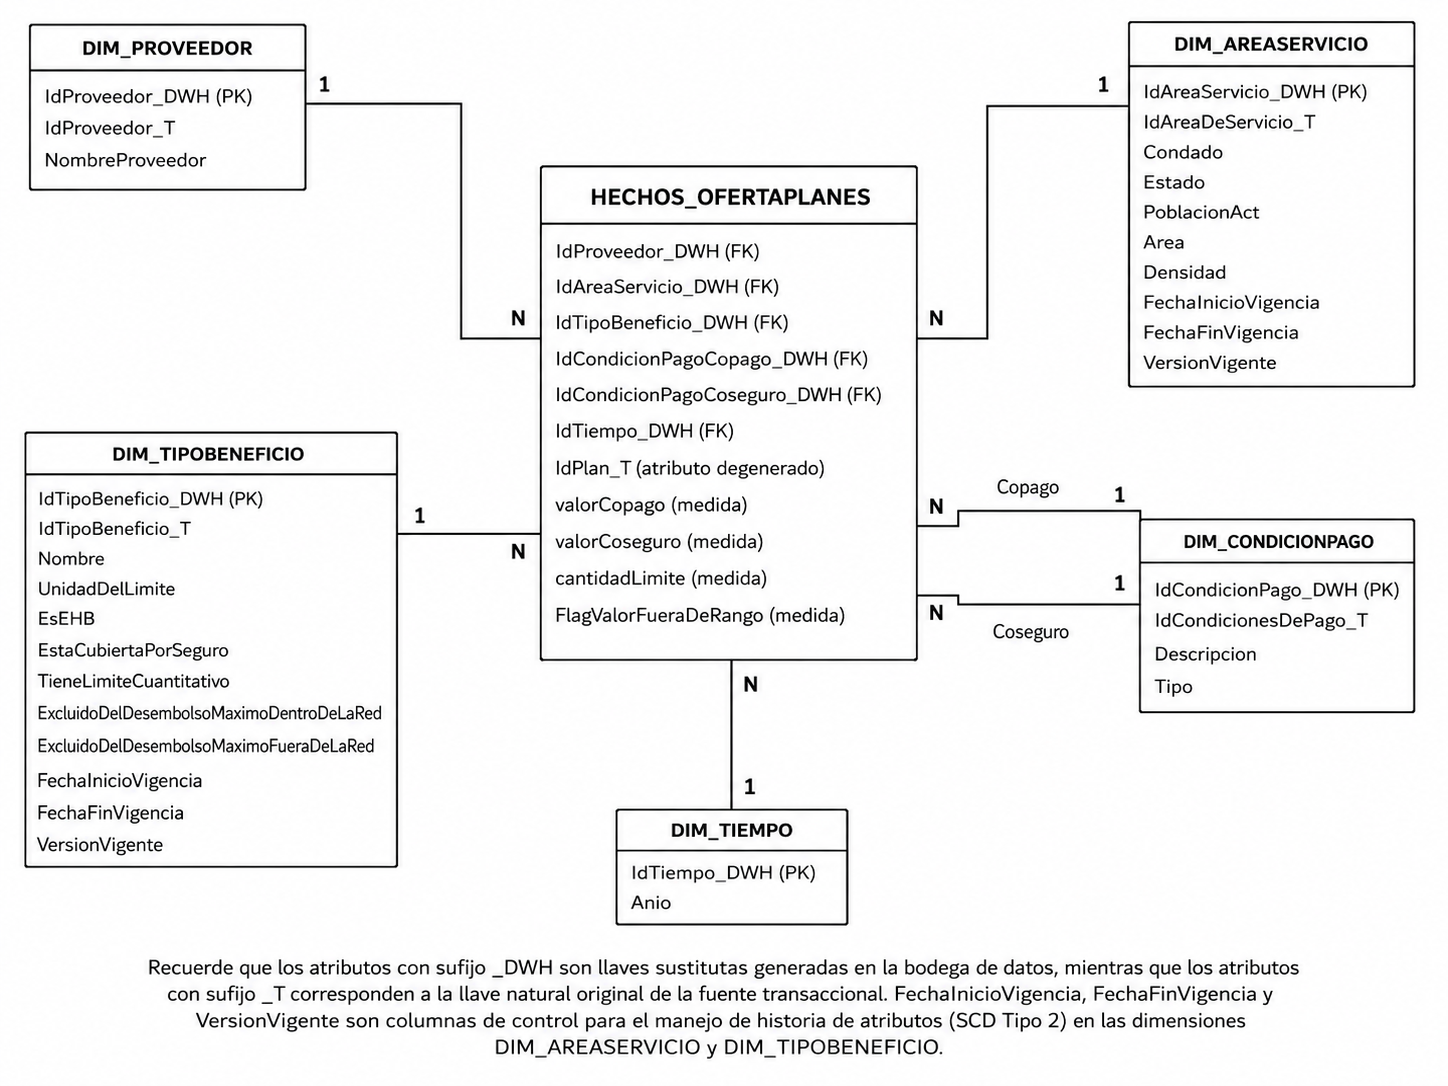